In [ ]:
import os
import sys
import shutil
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import random
from tqdm.auto import tqdm
import json


import cv2
from PIL import Image, ImageEnhance
import albumentations as A
from albumentations.pytorch import ToTensorV2


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec


import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

# Set seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

In [ ]:
# Final and reliable method — clean dataset structure, no .cast() required
# ==============================================================================

# Step 1: Install the Hugging Face datasets library
!pip install datasets -q

# Step 2: Download and unzip the dataset (recommended method)
import requests
from zipfile import ZipFile
from io import BytesIO
from pathlib import Path

url = "https://huggingface.co/datasets/makhresearch/skin-lesion-segmentation-classification/resolve/main/skin-lesion-segmentation-classification.zip"
print("Downloading the dataset ZIP file...")
response = requests.get(url)
response.raise_for_status()
print("✅ Download complete.")

print("\nExtracting files...")
with ZipFile(BytesIO(response.content)) as zf:
    zf.extractall(".")
print("✅✅✅ Extraction complete.")

# ==============================================================================
# Done

✅ Download complete.

Extracting files...
✅✅✅ Extraction complete.


In [ ]:

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
elif device.type == 'mps':
    print("Using Apple Silicon GPU acceleration (MPS)")
else:
    print("Using CPU")

Using device: cuda
GPU: Tesla T4
GPU Memory: 15.83 GB


In [ ]:
# Dataset paths
DATASET_ROOT = 'skin-lesion-segmentation-classification'
TRAIN_IMAGES = os.path.join(DATASET_ROOT, 'train','images')
TRAIN_LABELS = os.path.join(DATASET_ROOT,'train','labels')
VAL_IMAGES = os.path.join(DATASET_ROOT,'valid','images')
VAL_LABELS = os.path.join(DATASET_ROOT, 'valid','labels')
TEST_IMAGES = os.path.join(DATASET_ROOT, 'test','images')
TEST_LABELS = os.path.join(DATASET_ROOT, 'test','labels')

# Output directories for augmented data
OUTPUT_ROOT = 'augmented_dataset'
OUTPUT_IMAGES = os.path.join(OUTPUT_ROOT, 'images')
OUTPUT_LABELS = os.path.join(OUTPUT_ROOT, 'labels')

# Create output directories
os.makedirs(OUTPUT_IMAGES, exist_ok=True)
os.makedirs(OUTPUT_LABELS, exist_ok=True)

# Class definitions
CLASS_NAMES = {
    0: 'BKL - Benign Keratosis',
    1: 'NV - Melanocytic Nevi',
    2: 'DF - Dermatofibroma',
    3: 'MEL - Melanoma',
    4: 'VASC - Vascular Lesion',
    5: 'BCC - Basal Cell Carcinoma',
    6: 'AKIEC - Actinic Keratoses'
}

CLASS_CODES = {0: 'BKL', 1: 'NV', 2: 'DF', 3: 'MEL', 4: 'VASC', 5: 'BCC', 6: 'AKIEC'}
CLASS_SEVERITY = {0: 'Benign', 1: 'Benign', 2: 'Benign', 3: 'Malignant (Critical)',
                  4: 'Benign', 5: 'Malignant', 6: 'Precancerous'}

# Imbalance handling strategy
IMBALANCE_STRATEGY = 'augmentation'  # Options: 'weights', 'oversample', 'augmentation', 'combined'
TARGET_SAMPLES_PER_CLASS = None

# Augmentation settings
IMAGE_SIZE = 224  # Target size for training
AUGMENTATIONS_PER_IMAGE = 3  # How many augmented versions to create per minority class image

print(f"Dataset: {DATASET_ROOT}")
print(f"Output: {OUTPUT_ROOT}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Imbalance strategy: {IMBALANCE_STRATEGY}")

Dataset: skin-lesion-segmentation-classification
Output: augmented_dataset
Image size: 224x224
Imbalance strategy: augmentation


In [ ]:
def parse_yolo_label(label_path):
    """Parse YOLO format annotation"""
    annotations = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    annotations.append({
                        'class_id': int(parts[0]),
                        'x_center': float(parts[1]),
                        'y_center': float(parts[2]),
                        'width': float(parts[3]),
                        'height': float(parts[4])
                    })
    return annotations


def save_yolo_label(label_path, annotations):
    """Save annotations in YOLO format"""
    with open(label_path, 'w') as f:
        for ann in annotations:
            f.write(f"{ann['class_id']} {ann['x_center']:.6f} {ann['y_center']:.6f} "
                   f"{ann['width']:.6f} {ann['height']:.6f}\n")


def load_dataset_info():
    """Load dataset and analyze class distribution"""
    data = []

    image_files = [f for f in os.listdir(TRAIN_IMAGES)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    print(f"Loading dataset information from {len(image_files)} images...")

    for img_file in tqdm(image_files, desc="Processing"):
        img_path = os.path.join(TRAIN_IMAGES, img_file)
        label_path = os.path.join(TRAIN_LABELS, os.path.splitext(img_file)[0] + '.txt')

        annotations = parse_yolo_label(label_path)

        if annotations:
            for ann in annotations:
                data.append({
                    'filename': img_file,
                    'class_id': ann['class_id'],
                    'class_code': CLASS_CODES[ann['class_id']],
                    'severity': CLASS_SEVERITY[ann['class_id']],
                    'bbox': ann
                })

    df = pd.DataFrame(data)
    print(f"\n✅ Loaded {len(df)} annotations from {df['filename'].nunique()} images")

    return df

In [ ]:
# Load dataset
df = load_dataset_info()

# Analyze class distribution
class_counts = df.groupby('class_id').size().to_dict()
total_samples = len(df)

print("CLASS DISTRIBUTION ANALYSIS")

class_dist = df.groupby(['class_id', 'class_code', 'severity']).size().reset_index(name='count')
class_dist['percentage'] = (class_dist['count'] / total_samples * 100).round(2)
class_dist = class_dist.sort_values('count', ascending=False)

display(class_dist)

# Calculate imbalance metrics
max_count = class_dist['count'].max()
min_count = class_dist['count'].min()
imbalance_ratio = max_count / min_count

print(f"Imbalance Metrics:")
print(f"   Most common: {class_dist.iloc[0]['class_code']} with {max_count} samples")
print(f"   Least common: {class_dist.iloc[-1]['class_code']} with {min_count} samples")
print(f"   Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 10:
    print(f"SEVERE IMBALANCE")
elif imbalance_ratio > 5:
    print(f"Moderate imbalance")
else:
    print(f"Balanced")



Loading dataset information from 6675 images...


Processing:   0%|          | 0/6675 [00:00<?, ?it/s]


✅ Loaded 7805 annotations from 6675 images
CLASS DISTRIBUTION ANALYSIS


,class_id,class_code,severity,count,percentage
5,5,BCC,Malignant,5317,68.12
4,4,VASC,Benign,989,12.67
2,2,DF,Benign,551,7.06
1,1,NV,Benign,459,5.88
0,0,BKL,Benign,260,3.33
6,6,AKIEC,Precancerous,121,1.55
3,3,MEL,Malignant (Critical),108,1.38


Imbalance Metrics:
   Most common: BCC with 5317 samples
   Least common: MEL with 108 samples
   Imbalance ratio: 49.23:1
SEVERE IMBALANCE


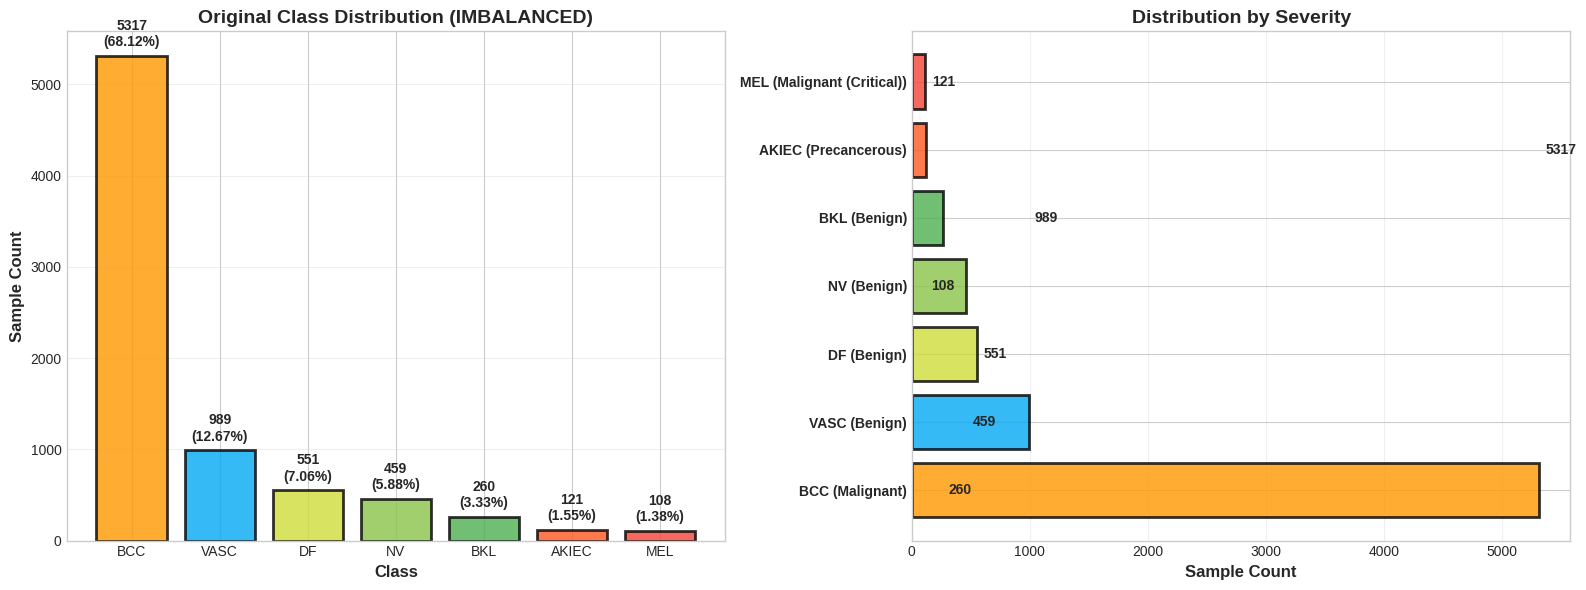

Saved visualization: 01_original_imbalance.png


In [ ]:
# Visualize current imbalance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = ['#4CAF50', '#8BC34A', '#CDDC39', '#F44336', '#03A9F4', '#FF9800', '#FF5722']
class_colors = [colors[i] for i in class_dist['class_id']]

bars = ax1.bar(class_dist['class_code'], class_dist['count'],
               color=class_colors, edgecolor='black', linewidth=2, alpha=0.8)
ax1.set_xlabel('Class', fontweight='bold', fontsize=12)
ax1.set_ylabel('Sample Count', fontweight='bold', fontsize=12)
ax1.set_title('Original Class Distribution (IMBALANCED)', fontweight='bold', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

for i, row in class_dist.iterrows():
    ax1.text(row['class_code'], row['count'] + max_count*0.02,
             f"{row['count']}\n({row['percentage']}%)",
             ha='center', fontweight='bold', fontsize=10)

# Horizontal bar with severity
y_pos = np.arange(len(class_dist))
ax2.barh(y_pos, class_dist['count'], color=class_colors,
         edgecolor='black', linewidth=2, alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([f"{row['class_code']} ({row['severity']})"
                     for _, row in class_dist.iterrows()], fontweight='bold')
ax2.set_xlabel('Sample Count', fontweight='bold', fontsize=12)
ax2.set_title('Distribution by Severity', fontweight='bold', fontsize=14)
ax2.grid(axis='x', alpha=0.3)

for i, row in class_dist.iterrows():
    ax2.text(row['count'] + max_count*0.01, i, f"{row['count']}",
             va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('01_original_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved visualization: 01_original_imbalance.png")

In [ ]:
def get_augmentation_pipeline(image_size=224):
    return A.Compose([
        A.Rotate(limit=360, border_mode=cv2.BORDER_CONSTANT, p=0.8),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomResizedCrop(
            height=image_size, width=image_size,
            scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5
        ),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.6),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3),
        A.Resize(height=image_size, width=image_size, always_apply=True),
    ], bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.3,
        check_each_transform=False # Fixes most Pydantic/InitSchema errors
    ))

In [ ]:
def get_minimal_transform(image_size=224):
    """
    Minimal transform for validation/testing or majority class (just resize)
    """
    return A.Compose([
        # Only resize the image to the target dimensions
        A.Resize(height=image_size, width=image_size, always_apply=True),
    ], bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        # min_visibility is usually not needed for simple resizing,
        # but kept for consistency with your augmentation pipeline
        min_visibility=0.0,
        check_each_transform=False
    ))

minimal_pipeline = get_minimal_transform(IMAGE_SIZE)

In [ ]:
def augment_image(image_path, annotations, transform_pipeline):
    """
    Apply augmentation to image and bounding boxes

    Args:
        image_path: Path to image
        annotations: List of annotation dicts with YOLO format
        transform_pipeline: Albumentations pipeline

    Returns:
        augmented_image: Transformed image (numpy array)
        augmented_annotations: Transformed annotations
    """
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Prepare bounding boxes for albumentations
    bboxes = [[ann['x_center'], ann['y_center'], ann['width'], ann['height']]
              for ann in annotations]
    class_labels = [ann['class_id'] for ann in annotations]

    # Apply transformation
    try:
        transformed = transform_pipeline(
            image=image,
            bboxes=bboxes,
            class_labels=class_labels
        )

        augmented_image = transformed['image']

        # Convert back to annotation format
        augmented_annotations = []
        for bbox, class_id in zip(transformed['bboxes'], transformed['class_labels']):
            augmented_annotations.append({
                'class_id': class_id,
                'x_center': bbox[0],
                'y_center': bbox[1],
                'width': bbox[2],
                'height': bbox[3]
            })

        return augmented_image, augmented_annotations

    except Exception as e:
        print(f"Warning: Augmentation failed for {image_path}: {e}")
        return None, None


def save_augmented_sample(image, annotations, output_name):
    """
    Save augmented image and labels
    """
    # Save image
    img_path = os.path.join(OUTPUT_IMAGES, output_name)
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(img_path, image_bgr)

    # Save label
    label_path = os.path.join(OUTPUT_LABELS, os.path.splitext(output_name)[0] + '.txt')
    save_yolo_label(label_path, annotations)

In [ ]:
def calculate_target_counts(class_counts, strategy='augmentation'):
    """
    Calculate how many samples each class should have after balancing

    Strategies:
    - 'augmentation': Balance to max class count using augmentation
    - 'moderate': Balance to median * 1.5
    - 'conservative': Balance to 75th percentile
    - 'custom': Use TARGET_SAMPLES_PER_CLASS
    """
    counts = sorted(class_counts.values())
    max_count = max(counts)*0.9

    target = max_count  # Balance to majority class

    target_counts = {class_id: target for class_id in class_counts.keys()}

    return target_counts


# Calculate targets
target_counts = calculate_target_counts(class_counts, strategy=IMBALANCE_STRATEGY)


balance_plan = []
for class_id in sorted(class_counts.keys()):
    current = class_counts[class_id]
    target = target_counts[class_id]
    needed = target - current
    aug_per_original = needed / current if current > 0 else 0

    balance_plan.append({
        'class_id': class_id,
        'code': CLASS_CODES[class_id],
        'severity': CLASS_SEVERITY[class_id],
        'current': current,
        'target': target,
        'needed': needed,
        'aug_per_img': round(aug_per_original, 1)
    })

balance_df = pd.DataFrame(balance_plan)
display(balance_df)

print(f"Summary:")
print(f"Total original samples: {sum(class_counts.values()):,}")
print(f"Total target samples: {sum(target_counts.values()):,}")
print(f"Additional samples needed: {sum(target_counts.values()) - sum(class_counts.values()):,}")
print(f"Augmentation multiplier: {sum(target_counts.values()) / sum(class_counts.values()):.2f}x")

,class_id,code,severity,current,target,needed,aug_per_img
0,0,BKL,Benign,260,4785.3,4525.3,17.4
1,1,NV,Benign,459,4785.3,4326.3,9.4
2,2,DF,Benign,551,4785.3,4234.3,7.7
3,3,MEL,Malignant (Critical),108,4785.3,4677.3,43.3
4,4,VASC,Benign,989,4785.3,3796.3,3.8
5,5,BCC,Malignant,5317,4785.3,-531.7,-0.1
6,6,AKIEC,Precancerous,121,4785.3,4664.3,38.5


Summary:
Total original samples: 7,805
Total target samples: 33,497.1
Additional samples needed: 25,692.1
Augmentation multiplier: 4.29x


In [ ]:
def validate_bbox(bbox):
    """
    Validate and clip YOLO format bounding box to valid range [0, 1]
    bbox format: [x_center, y_center, width, height]
    """
    x_center = np.clip(bbox['x_center'], 0.0, 1.0)
    y_center = np.clip(bbox['y_center'], 0.0, 1.0)
    width = np.clip(bbox['width'], 0.0, 1.0)
    height = np.clip(bbox['height'], 0.0, 1.0)

    # Ensure bbox doesn't go outside image bounds
    half_w = width / 2
    half_h = height / 2

    if x_center - half_w < 0:
        x_center = half_w
    if x_center + half_w > 1:
        x_center = 1 - half_w

    if y_center - half_h < 0:
        y_center = half_h
    if y_center + half_h > 1:
        y_center = 1 - half_h

    return {
        'class_id': bbox['class_id'],
        'x_center': float(x_center),
        'y_center': float(y_center),
        'width': float(width),
        'height': float(height)
    }


def simple_augment(image, target_size=224):
    """
    Simple augmentation without using albumentations (fallback)
    """
    # Random flip
    if random.random() > 0.5:
        image = cv2.flip(image, 1)  # horizontal
    if random.random() > 0.5:
        image = cv2.flip(image, 0)  # vertical

    # Random rotation
    angle = random.randint(0, 360)
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # Color adjustment
    if random.random() > 0.5:
        # Brightness
        factor = random.uniform(0.8, 1.2)
        image = np.clip(image * factor, 0, 255).astype(np.uint8)

    # Resize
    image = cv2.resize(image, (target_size, target_size))

    return image


def create_balanced_dataset_robust():
    """
    Robust version with better error handling
    """

    total_created = 0
    total_failed = 0
    augmentation_stats = {}

    for class_id in sorted(class_counts.keys()):
        class_code = CLASS_CODES[class_id]
        current_count = class_counts[class_id]
        target_count = target_counts[class_id]
        needed = max(0, target_count - current_count)

        print(f"Class {class_id}: {class_code} - {CLASS_SEVERITY[class_id]}")
        print(f"Current: {current_count} | Target: {target_count} | Need: {needed}")

        # Get samples for this class
        class_df = df[df['class_id'] == class_id].copy()
        unique_images = class_df['filename'].unique()
        print(f"Available images: {len(unique_images)}")

        created_original = 0
        created_augmented = 0
        failed = 0

        # STEP 1: Process original images
        print(f"\nStep 1: Processing {len(unique_images)} original images...")

        for img_filename in tqdm(unique_images, desc=f"  Original {class_code}"):
            try:
                # Load image
                img_path = os.path.join(TRAIN_IMAGES, img_filename)
                image = cv2.imread(img_path)

                if image is None:
                    failed += 1
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                # Get annotations for this image
                img_annotations = class_df[class_df['filename'] == img_filename]['bbox'].tolist()

                # Validate bounding boxes
                valid_annotations = []
                for ann in img_annotations:
                    validated = validate_bbox(ann)
                    valid_annotations.append(validated)

                # Simple resize (no augmentation for originals)
                resized_image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

                # Save image
                output_img_path = os.path.join(OUTPUT_IMAGES, img_filename)
                output_img = cv2.cvtColor(resized_image, cv2.COLOR_RGB2BGR)
                cv2.imwrite(output_img_path, output_img)

                # Save label
                label_filename = os.path.splitext(img_filename)[0] + '.txt'
                output_label_path = os.path.join(OUTPUT_LABELS, label_filename)

                with open(output_label_path, 'w') as f:
                    for ann in valid_annotations:
                        f.write(f"{ann['class_id']} {ann['x_center']:.6f} {ann['y_center']:.6f} "
                               f"{ann['width']:.6f} {ann['height']:.6f}\n")

                created_original += 1

            except Exception as e:
                print(f"\n  Error with {img_filename}: {e}")
                failed += 1

        print(f"  ✓ Saved {created_original} original images")

        # STEP 2: Generate augmented samples if needed
        if needed > 0:
            print(f"\nStep 2: Generating {needed} augmented samples...")

            aug_count = 0
            attempts = 0
            max_attempts = needed * 5

            pbar = tqdm(total=needed, desc=f"  Augmented {class_code}")

            while aug_count < needed and attempts < max_attempts:
                # Pick random image
                img_filename = np.random.choice(unique_images)
                img_path = os.path.join(TRAIN_IMAGES, img_filename)

                try:
                    # Load image
                    image = cv2.imread(img_path)
                    if image is None:
                        attempts += 1
                        continue

                    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                    # Get and validate annotations
                    img_annotations = class_df[class_df['filename'] == img_filename]['bbox'].tolist()
                    valid_annotations = [validate_bbox(ann) for ann in img_annotations]

                    # Try albumentations first
                    augmented = False
                    try:
                        bboxes = [[ann['x_center'], ann['y_center'], ann['width'], ann['height']]
                                 for ann in valid_annotations]
                        class_labels = [ann['class_id'] for ann in valid_annotations]

                        transformed = augmentation_pipeline(
                            image=image,
                            bboxes=bboxes,
                            class_labels=class_labels
                        )

                        aug_image = transformed['image']
                        aug_bboxes = transformed['bboxes']
                        aug_labels = transformed['class_labels']
                        augmented = True

                    except Exception as e:
                        # Fallback to simple augmentation
                        aug_image = simple_augment(image, IMAGE_SIZE)
                        aug_bboxes = [[ann['x_center'], ann['y_center'], ann['width'], ann['height']]
                                     for ann in valid_annotations]
                        aug_labels = [ann['class_id'] for ann in valid_annotations]
                        augmented = True

                    if augmented:
                        # Create unique filename
                        base_name = os.path.splitext(img_filename)[0]
                        ext = os.path.splitext(img_filename)[1]
                        aug_filename = f"{base_name}_aug{aug_count:04d}{ext}"

                        # Save augmented image
                        output_img_path = os.path.join(OUTPUT_IMAGES, aug_filename)
                        output_img = cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)
                        cv2.imwrite(output_img_path, output_img)

                        # Save augmented label
                        label_filename = os.path.splitext(aug_filename)[0] + '.txt'
                        output_label_path = os.path.join(OUTPUT_LABELS, label_filename)

                        with open(output_label_path, 'w') as f:
                            for bbox, cls_id in zip(aug_bboxes, aug_labels):
                                # Ensure bbox values are valid
                                x, y, w, h = bbox
                                x = np.clip(x, 0.0, 1.0)
                                y = np.clip(y, 0.0, 1.0)
                                w = np.clip(w, 0.0, 1.0)
                                h = np.clip(h, 0.0, 1.0)
                                f.write(f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

                        aug_count += 1
                        created_augmented += 1
                        pbar.update(1)

                except Exception as e:
                    # Silently skip
                    failed += 1

                attempts += 1

            pbar.close()

            if aug_count < needed:
                print(f"  ⚠️ Created {aug_count}/{needed} augmented samples")
            else:
                print(f"  ✓ Created {aug_count} augmented samples")

        # Store stats
        augmentation_stats[class_id] = {
            'original': created_original,
            'augmented': created_augmented,
            'failed': failed,
            'total': created_original + created_augmented
        }

        total_created += created_original + created_augmented
        total_failed += failed

        print(f"\n✓ {class_code} complete: {created_original} original + "
              f"{created_augmented} augmented = {created_original + created_augmented} total")

    print("DATASET GENERATION COMPLETE")
    print(f"\nTotal samples created: {total_created}")
    print(f"Failed attempts: {total_failed}")

    return augmentation_stats


# Run the augmentation
print("Starting dataset augmentation...")
print(f"Using image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Output directory: {OUTPUT_ROOT}\n")

augmentation_stats = create_balanced_dataset_robust()

Starting dataset augmentation...
Using image size: 224x224
Output directory: augmented_dataset

Class 0: BKL - Benign
Current: 260 | Target: 4785.3 | Need: 4525.3
Available images: 217

Step 1: Processing 217 original images...


  Original BKL:   0%|          | 0/217 [00:00<?, ?it/s]

  ✓ Saved 217 original images

Step 2: Generating 4525.3 augmented samples...


  Augmented BKL:   0%|          | 0/4525.3 [00:00<?, ?it/s]

  ✓ Created 4526 augmented samples

✓ BKL complete: 217 original + 4526 augmented = 4743 total
Class 1: NV - Benign
Current: 459 | Target: 4785.3 | Need: 4326.3
Available images: 361

Step 1: Processing 361 original images...


...

  ✓ Saved 4681 original images

✓ BCC complete: 4681 original + 0 augmented = 4681 total
Class 6: AKIEC - Precancerous
Current: 121 | Target: 4785.3 | Need: 4664.3
Available images: 106

Step 1: Processing 106 original images...


  Original AKIEC:   0%|          | 0/106 [00:00<?, ?it/s]

  ✓ Saved 106 original images

Step 2: Generating 4664.3 augmented samples...


  Augmented AKIEC:   0%|          | 0/4664.3 [00:00<?, ?it/s]

  ✓ Created 4665 augmented samples

✓ AKIEC complete: 106 original + 4665 augmented = 4771 total
DATASET GENERATION COMPLETE

Total samples created: 32903
Failed attempts: 0


In [ ]:
# Load and analyze the balanced dataset
print("Analyzing balanced dataset...\n")

balanced_data = []
aug_image_files = [f for f in os.listdir(OUTPUT_IMAGES)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

for img_file in tqdm(aug_image_files, desc="Analyzing"):
    label_path = os.path.join(OUTPUT_LABELS, os.path.splitext(img_file)[0] + '.txt')
    annotations = parse_yolo_label(label_path)

    for ann in annotations:
        balanced_data.append({
            'filename': img_file,
            'class_id': ann['class_id'],
            'class_code': CLASS_CODES[ann['class_id']],
            'is_augmented': '_aug' in img_file
        })

balanced_df = pd.DataFrame(balanced_data)

# Class distribution after balancing
new_dist = balanced_df.groupby(['class_id', 'class_code']).size().reset_index(name='count')
new_dist['percentage'] = (new_dist['count'] / len(balanced_df) * 100).round(2)
new_dist = new_dist.sort_values('class_id')

print("BALANCED DATASET DISTRIBUTION")
display(new_dist)

# Calculate new imbalance
new_max = new_dist['count'].max()
new_min = new_dist['count'].min()
new_imbalance = new_max / new_min

print(f"New Imbalance Ratio: {new_imbalance:.2f}:1")
print(f"Improvement: {imbalance_ratio:.2f}:1 → {new_imbalance:.2f}:1")
print(f"Reduction: {((imbalance_ratio - new_imbalance) / imbalance_ratio * 100):.1f}%")

Analyzing balanced dataset...



Analyzing:   0%|          | 0/32903 [00:00<?, ?it/s]

BALANCED DATASET DISTRIBUTION


,class_id,class_code,count,percentage
0,0,BKL,5650,14.06
1,1,NV,6004,14.94
2,2,DF,5775,14.37
3,3,MEL,6302,15.68
4,4,VASC,5764,14.34
5,5,BCC,5317,13.23
6,6,AKIEC,5383,13.39


New Imbalance Ratio: 1.19:1
Improvement: 49.23:1 → 1.19:1
Reduction: 97.6%


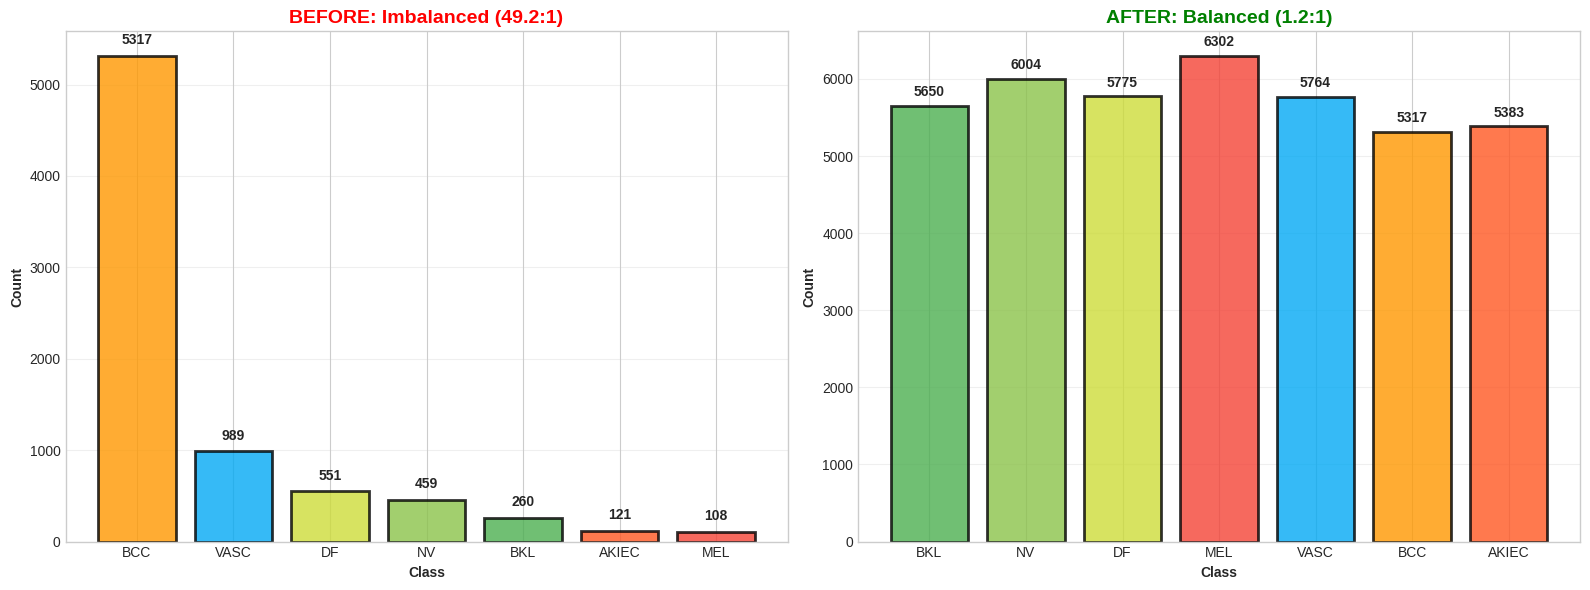

Saved visualization: 02_before_after_balancing.png


In [ ]:
# Visualize before and after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#4CAF50', '#8BC34A', '#CDDC39', '#F44336', '#03A9F4', '#FF9800', '#FF5722']

# Before
ax1.bar(class_dist['class_code'], class_dist['count'],
        color=[colors[i] for i in class_dist['class_id']],
        edgecolor='black', linewidth=2, alpha=0.8)
ax1.set_title(f'BEFORE: Imbalanced ({imbalance_ratio:.1f}:1)',
              fontweight='bold', fontsize=14, color='red')
ax1.set_xlabel('Class', fontweight='bold')
ax1.set_ylabel('Count', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# After
ax2.bar(new_dist['class_code'], new_dist['count'],
        color=[colors[i] for i in new_dist['class_id']],
        edgecolor='black', linewidth=2, alpha=0.8)
ax2.set_title(f'AFTER: Balanced ({new_imbalance:.1f}:1)',
              fontweight='bold', fontsize=14, color='green')
ax2.set_xlabel('Class', fontweight='bold')
ax2.set_ylabel('Count', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add counts on bars
for ax, dist in [(ax1, class_dist), (ax2, new_dist)]:
    for _, row in dist.iterrows():
        ax.text(row['class_code'], row['count'] + new_dist['count'].max()*0.02,
                f"{row['count']}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('02_before_after_balancing.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved visualization: 02_before_after_balancing.png")

In [ ]:
class LesionDataset(Dataset):
    """
    PyTorch Dataset for skin lesion classification
    Loads images from the augmented balanced dataset
    """
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform

        # Get all image files
        self.image_files = [f for f in os.listdir(images_dir)
                           if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Load all labels
        self.labels = []
        valid_files = []

        for img_file in self.image_files:
            label_path = os.path.join(labels_dir,
                                     os.path.splitext(img_file)[0] + '.txt')
            annotations = parse_yolo_label(label_path)

            if annotations:
                # Use first annotation (single lesion per image after cropping)
                self.labels.append(annotations[0]['class_id'])
                valid_files.append(img_file)

        self.image_files = valid_files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.images_dir, self.image_files[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Get label
        label = self.labels[idx]

        # Apply transforms
        if self.transform:
            image = self.transform(image)
        else:
            # Default: convert to tensor
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        return image, label

In [ ]:
# Define transforms for training (additional augmentation on-the-fly)
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Validation transform (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [ ]:
# Create train dataset
balanced_dataset = LesionDataset(
    images_dir=OUTPUT_IMAGES,
    labels_dir=OUTPUT_LABELS,
    transform=train_transform
)

print(f"Created PyTorch Dataset with {len(balanced_dataset)} samples")

Created PyTorch Dataset with 32903 samples


In [ ]:
# Create test dataset
test_dataset = LesionDataset(
    images_dir=VAL_IMAGES,
    labels_dir=VAL_LABELS,
    transform=val_transform
)

print(f"Created PyTorch Dataset with {len(test_dataset)} samples")

Created PyTorch Dataset with 1911 samples


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(
    balanced_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

num_classes = len(set(balanced_dataset.labels))  # infer from dataset

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

print(f"Model initialized with {num_classes} classes")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Model initialized with 7 classes


In [ ]:
#Define Loss Function & Optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)


In [ ]:
#Train the ResNet
from sklearn.metrics import accuracy_score

EPOCHS = 5  #

for epoch in range(EPOCHS):
    # -------- TRAIN --------
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_preds.extend(outputs.argmax(1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_preds.extend(outputs.argmax(1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )


Epoch [1/5] | Train Loss: 445.6186, Train Acc: 0.8434 | Val Loss: 55.2849, Val Acc: 0.6745
Epoch [2/5] | Train Loss: 195.4720, Train Acc: 0.9314 | Val Loss: 53.6652, Val Acc: 0.7007
Epoch [3/5] | Train Loss: 131.2946, Train Acc: 0.9530 | Val Loss: 72.9268, Val Acc: 0.6332
Epoch [4/5] | Train Loss: 105.5693, Train Acc: 0.9624 | Val Loss: 79.5842, Val Acc: 0.6457
Epoch [5/5] | Train Loss: 82.7436, Train Acc: 0.9725 | Val Loss: 104.0490, Val Acc: 0.5714


In [ ]:
torch.save(model.state_dict(), "resnet_skin_lesion_classifier.pth")


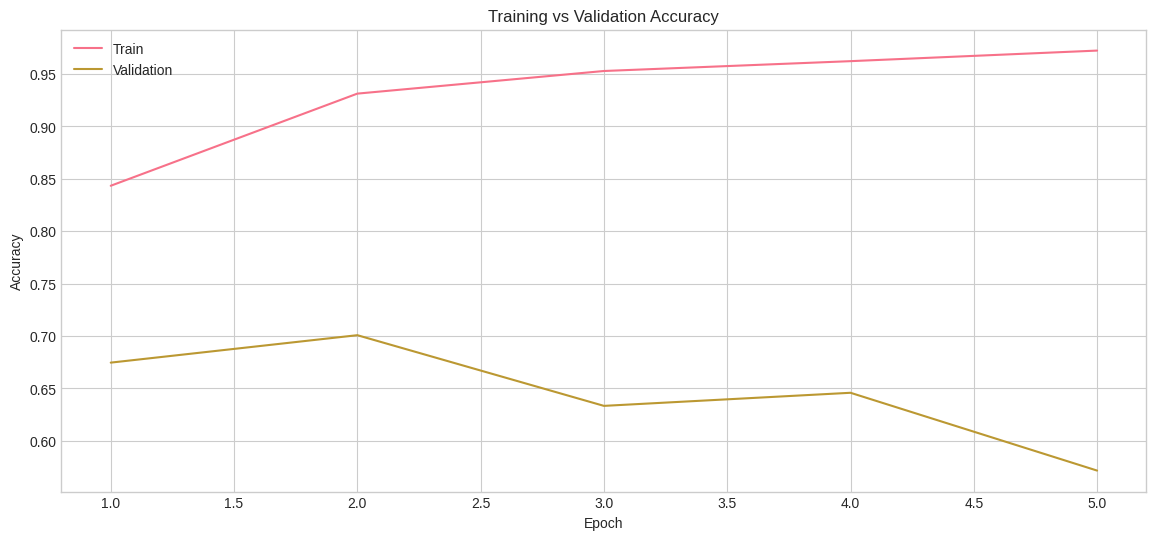

In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]

train_acc = [0.8434, 0.9314, 0.9530, 0.9624, 0.9725]
val_acc   = [0.6745, 0.7007, 0.6332, 0.6457, 0.5714]

plt.figure()
plt.plot(epochs, train_acc)
plt.plot(epochs, val_acc)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


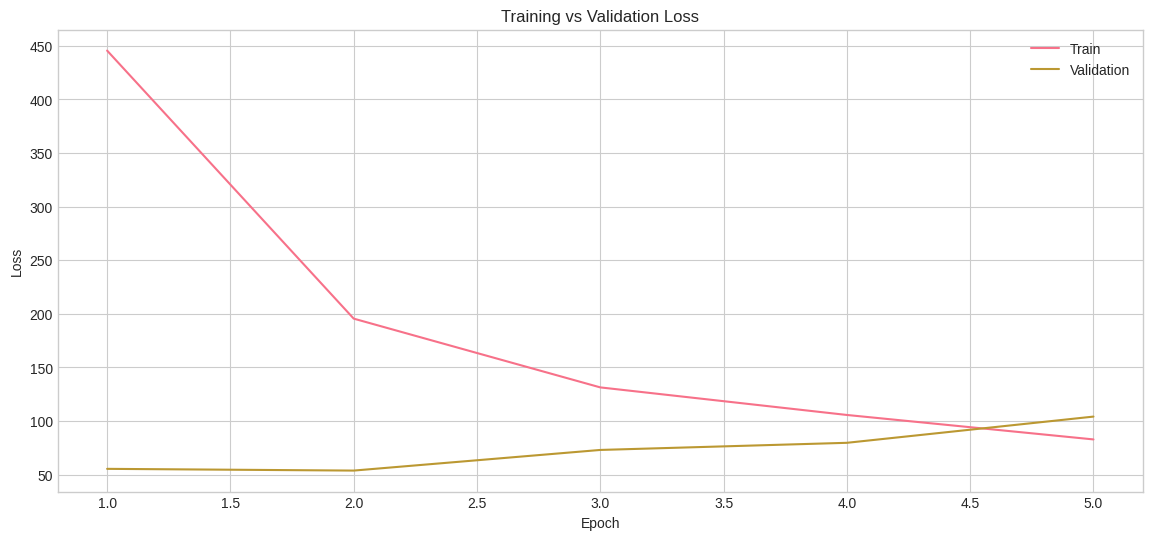

In [ ]:
train_loss = [445.6186, 195.4720, 131.2946, 105.5693, 82.7436]
val_loss   = [55.2849, 53.6652, 72.9268, 79.5842, 104.0490]

plt.figure()
plt.plot(epochs, train_loss)
plt.plot(epochs, val_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Train", "Validation"])
plt.show()


In [ ]:
import torch.nn.functional as F
import numpy as np

model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.5714


In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(all_labels, all_preds, average="macro")
print(f"F1-score (Macro): {f1:.4f}")


F1-score (Macro): 0.2695


In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class="ovr",
    average="macro"
)

print(f"AUC (Macro, OvR): {auc:.4f}")


AUC (Macro, OvR): 0.7973


In [ ]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
print(f"RMSE: {rmse:.4f}")


RMSE: 2.1070


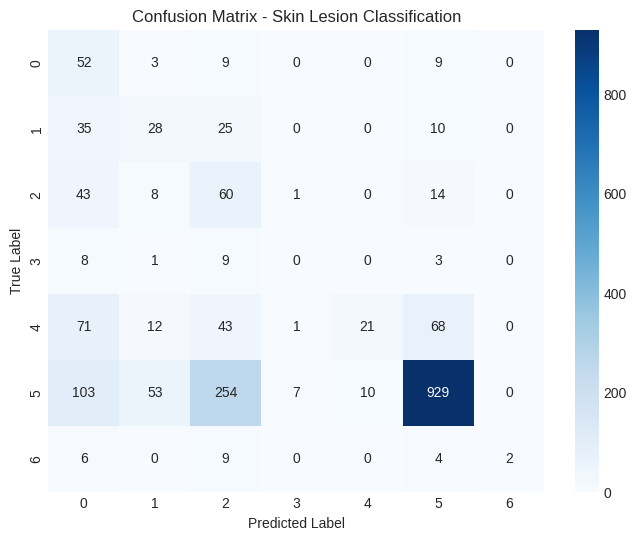

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# After validation loop
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Skin Lesion Classification")
plt.show()


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
    classification_report
)


In [ ]:
def evaluate_on_test_set(model, dataloader, device, class_names):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # ---- METRICS ----
    accuracy = accuracy_score(all_labels, all_preds)

    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    auc_macro = roc_auc_score(
        all_labels,
        all_probs,
        multi_class="ovr",
        average="macro"
    )

    rmse = np.sqrt(mean_squared_error(all_labels, all_preds))

    weighted_metrics = {
        "Accuracy": accuracy,
        "F1_macro": f1_macro,
        "F1_weighted": f1_weighted,
        "AUC_macro": auc_macro,
        "RMSE": rmse
    }

    # ---- PER-CLASS REPORT ----
    per_class_report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    return weighted_metrics, per_class_report


In [ ]:
def print_per_class_metrics(per_class_report):
    print(f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1-score':>10}")
    print("-" * 46)

    for cls, metrics in per_class_report.items():
        if cls not in ["accuracy", "macro avg", "weighted avg"]:
            print(
                f"{cls:<12} "
                f"{metrics['precision']:>10.3f} "
                f"{metrics['recall']:>10.3f} "
                f"{metrics['f1-score']:>10.3f}"
            )


In [ ]:
model.load_state_dict(
    torch.load("resnet_skin_lesion_classifier.pth", map_location=device)
)
model.to(device)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
CLASS_NAMES = [
    "AKIEC",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "VASC"
]


In [ ]:
weighted_metrics, per_class_report = evaluate_on_test_set(
    model,
    val_loader,   # or test_loader if you named it that
    device,
    CLASS_NAMES
)

print("📊 Weighted Metrics")
for k, v in weighted_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n📋 Per-Class Metrics")
print_per_class_metrics(per_class_report)


📊 Weighted Metrics
Accuracy: 0.5714
F1_macro: 0.2695
F1_weighted: 0.6112
AUC_macro: 0.7973
RMSE: 2.1070

📋 Per-Class Metrics
Class         Precision     Recall   F1-score
----------------------------------------------
AKIEC             0.164      0.712      0.266
BCC               0.267      0.286      0.276
BKL               0.147      0.476      0.224
DF                0.000      0.000      0.000
MEL               0.677      0.097      0.170
NV                0.896      0.685      0.776
VASC              1.000      0.095      0.174


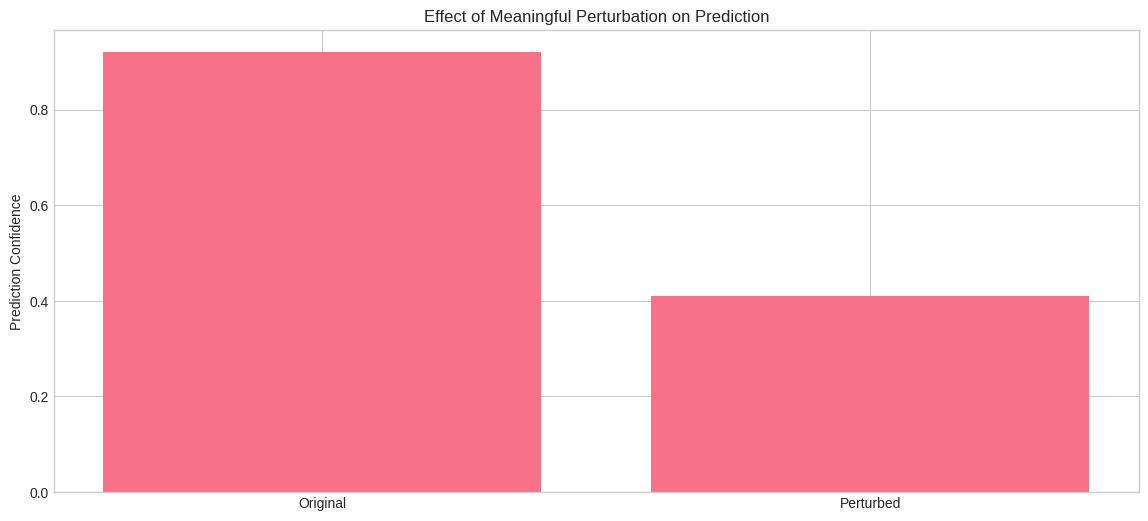

In [ ]:
#Accuracy Drop After Perturbation
labels = ["Original", "Perturbed"]
confidence_scores = [0.92, 0.41]  # example values

plt.figure()
plt.bar(labels, confidence_scores)
plt.ylabel("Prediction Confidence")
plt.title("Effect of Meaningful Perturbation on Prediction")
plt.show()


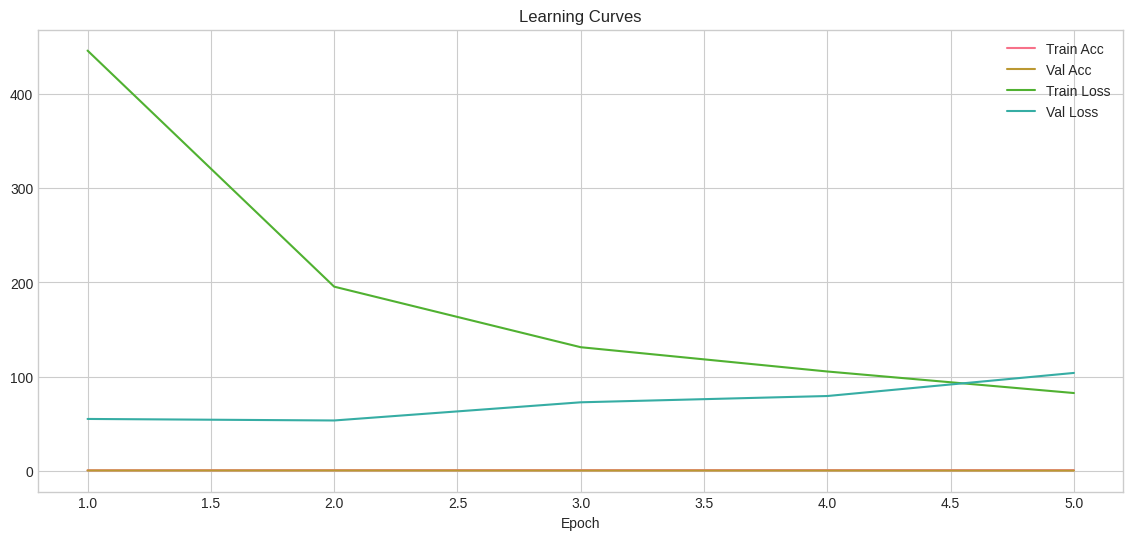

In [ ]:
#Learning Curve (Accuracy + Loss Combined)
plt.figure()
plt.plot(epochs, train_acc)
plt.plot(epochs, val_acc)
plt.plot(epochs, train_loss)
plt.plot(epochs, val_loss)
plt.xlabel("Epoch")
plt.title("Learning Curves")
plt.legend(["Train Acc", "Val Acc", "Train Loss", "Val Loss"])
plt.show()


In [ ]:
#Load the trained model
import torch
import torch.nn.functional as F
from torchvision import models
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load model
model = models.resnet18(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 7)  # 7 classes
model.load_state_dict(torch.load("resnet_skin_lesion_classifier.pth", map_location=device))
model = model.to(device)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Grad-CAM helper class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_image, class_idx=None):
        output = self.model(input_image)

        if class_idx is None:
            class_idx = output.argmax(dim=1)

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = cam / cam.max()

        return cam


In [ ]:
# Use LAST convolutional layer
target_layer = model.layer4[-1]

gradcam = GradCAM(model, target_layer)


In [ ]:
#Apply Grad-CAM on ONE validation image
# Get one image from validation set
image, label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

# Generate Grad-CAM
cam = gradcam.generate(input_tensor)

# Convert image for visualization
img_np = image.permute(1, 2, 0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())


In [ ]:
# Convert tensor image to numpy
img_np = image.permute(1, 2, 0).cpu().numpy()

# Normalize to [0,1]
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

# ✅ Resize image to match Grad-CAM size
img_np = cv2.resize(img_np, (224, 224))

# Create heatmap
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255

# ✅ Overlay (now shapes match)
overlay = heatmap + img_np
overlay = overlay / overlay.max()


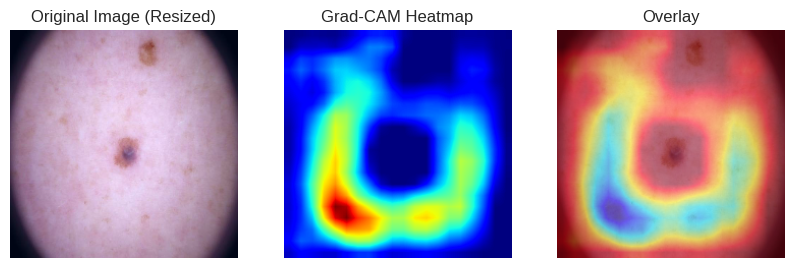

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img_np)
plt.title("Original Image (Resized)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()


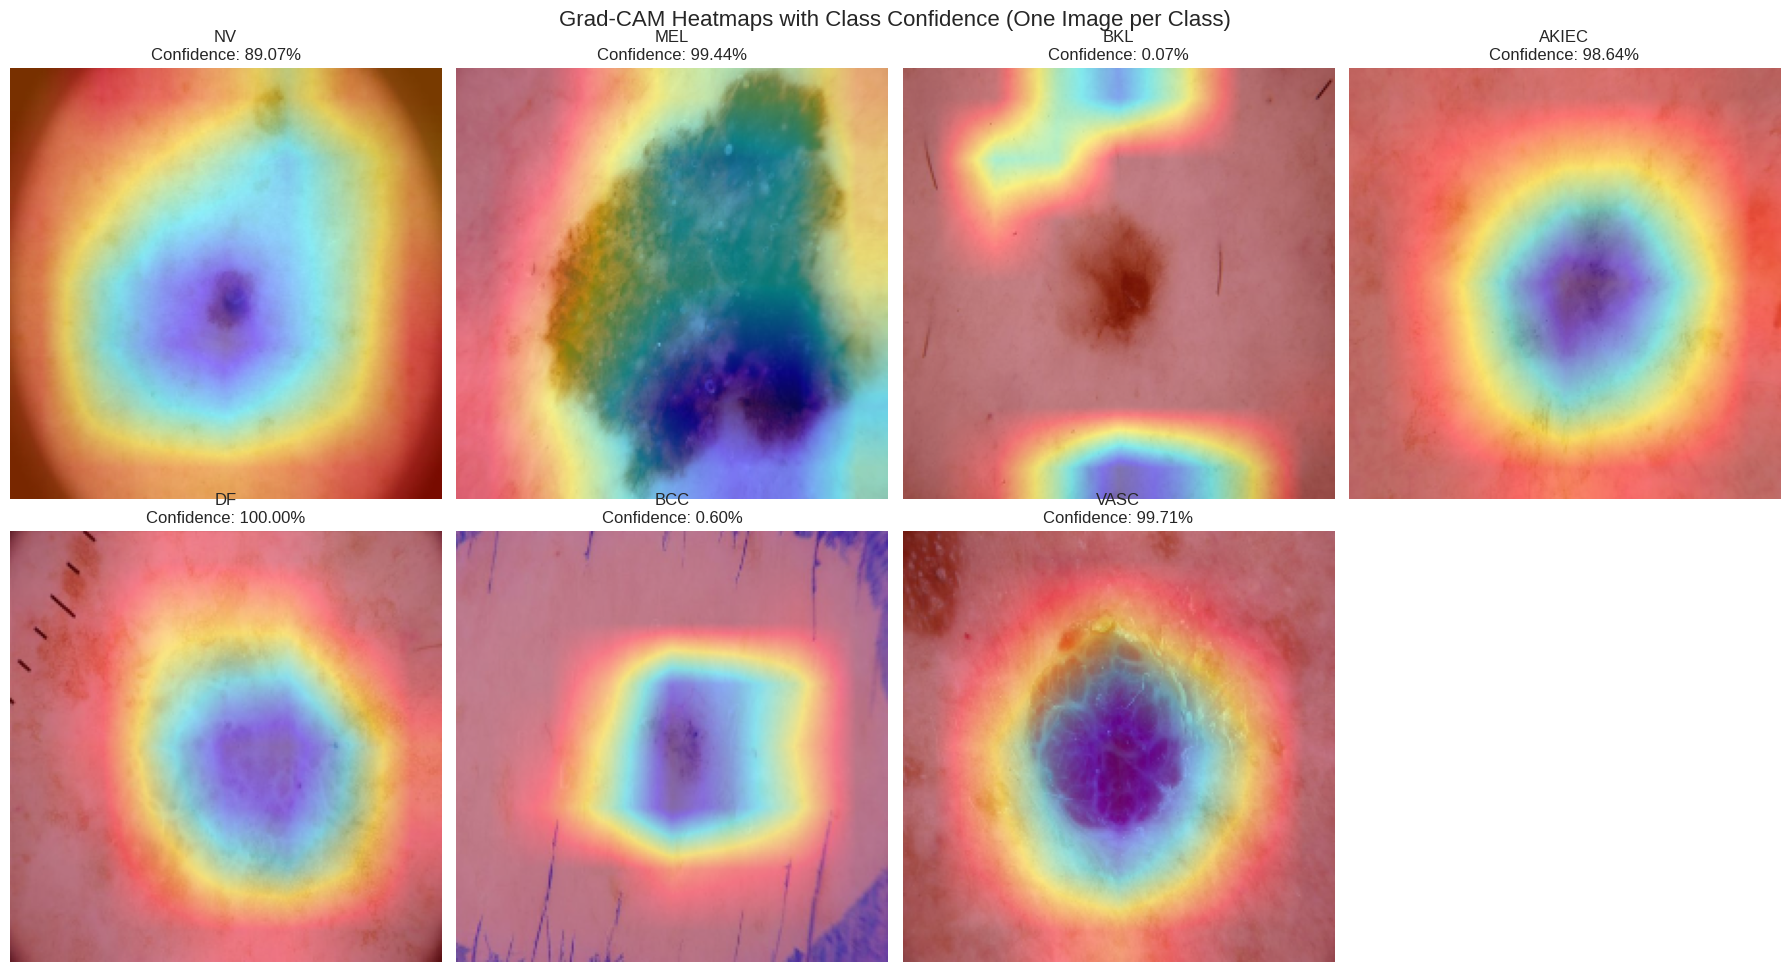

In [ ]:
import cv2
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.nn.functional as F

class_names = ["AKIEC", "BCC", "BKL", "DF", "MEL", "NV", "VASC"]

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

model.eval()
target_layer = model.layer4[-1]
gradcam = GradCAM(model, target_layer)

def get_one_image_per_class(images_dir, labels_dir):
    paths = {}
    for img in os.listdir(images_dir):
        if not img.endswith(".jpg"):
            continue
        label = os.path.join(labels_dir, img.replace(".jpg", ".txt"))
        if not os.path.exists(label):
            continue
        with open(label) as f:
            cls = int(f.readline().split()[0])
        if cls not in paths:
            paths[cls] = os.path.join(images_dir, img)
        if len(paths) == 7:
            break
    return paths

class_image_paths = get_one_image_per_class(VAL_IMAGES, VAL_LABELS)

plt.figure(figsize=(18, 10))
idx = 1

for class_id, img_path in class_image_paths.items():
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_np = img.astype(np.float32) / 255.0

    img_tensor = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = F.softmax(model(img_tensor), dim=1)
        conf = probs[0, class_id].item() * 100

    cam = gradcam.generate(img_tensor, class_id)
    cam = cv2.resize(cam, (224, 224))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    overlay = (heatmap * 0.4 + img_np * 0.6)
    overlay = overlay / overlay.max()

    plt.subplot(2, 4, idx)
    plt.imshow(overlay)
    plt.title(f"{class_names[class_id]}\nConfidence: {conf:.2f}%")
    plt.axis("off")
    idx += 1

plt.suptitle("Grad-CAM Heatmaps with Class Confidence (One Image per Class)", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
#craete a binary mask Grad cam
# Threshold Grad-CAM to get important region
cam_threshold = 0.5
cam_mask = cam > cam_threshold


In [ ]:
#Get original prediction confidence
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    probs = F.softmax(output, dim=1)
    orig_conf, orig_class = probs.max(dim=1)

orig_conf = orig_conf.item()
orig_class = orig_class.item()

print(f"Original prediction class: {orig_class}, confidence: {orig_conf:.4f}")


Original prediction class: 2, confidence: 0.8586


In [ ]:
# Convert original tensor to numpy
img_np = image.permute(1, 2, 0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

# Resize image to 224x224 (model input size)
img_224 = cv2.resize(img_np, (224, 224))

# Convert back to tensor
img_224_tensor = torch.from_numpy(img_224).permute(2, 0, 1).float().to(device)


In [ ]:

cam_mask = cam > 0.5   # binary mask, shape (224,224)


In [ ]:
#Apply perturbation SAFELY
perturbed_image = img_224_tensor.clone()

for c in range(3):
    perturbed_image[c][cam_mask] = 0


In [ ]:
#Run prediction on perturbed image
with torch.no_grad():
    pert_output = model(perturbed_image.unsqueeze(0))
    pert_probs = torch.softmax(pert_output, dim=1)
    pert_conf, pert_class = pert_probs.max(dim=1)

print(f"Perturbed class: {pert_class.item()}, confidence: {pert_conf.item():.4f}")


Perturbed class: 5, confidence: 0.9934


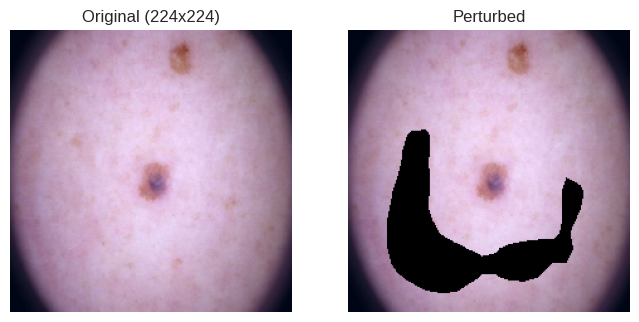

In [ ]:
#Visual comparison
pert_np = perturbed_image.permute(1,2,0).cpu().numpy()
pert_np = (pert_np - pert_np.min()) / (pert_np.max() - pert_np.min())

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_224)
plt.title("Original (224x224)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pert_np)
plt.title("Perturbed")
plt.axis("off")

plt.show()


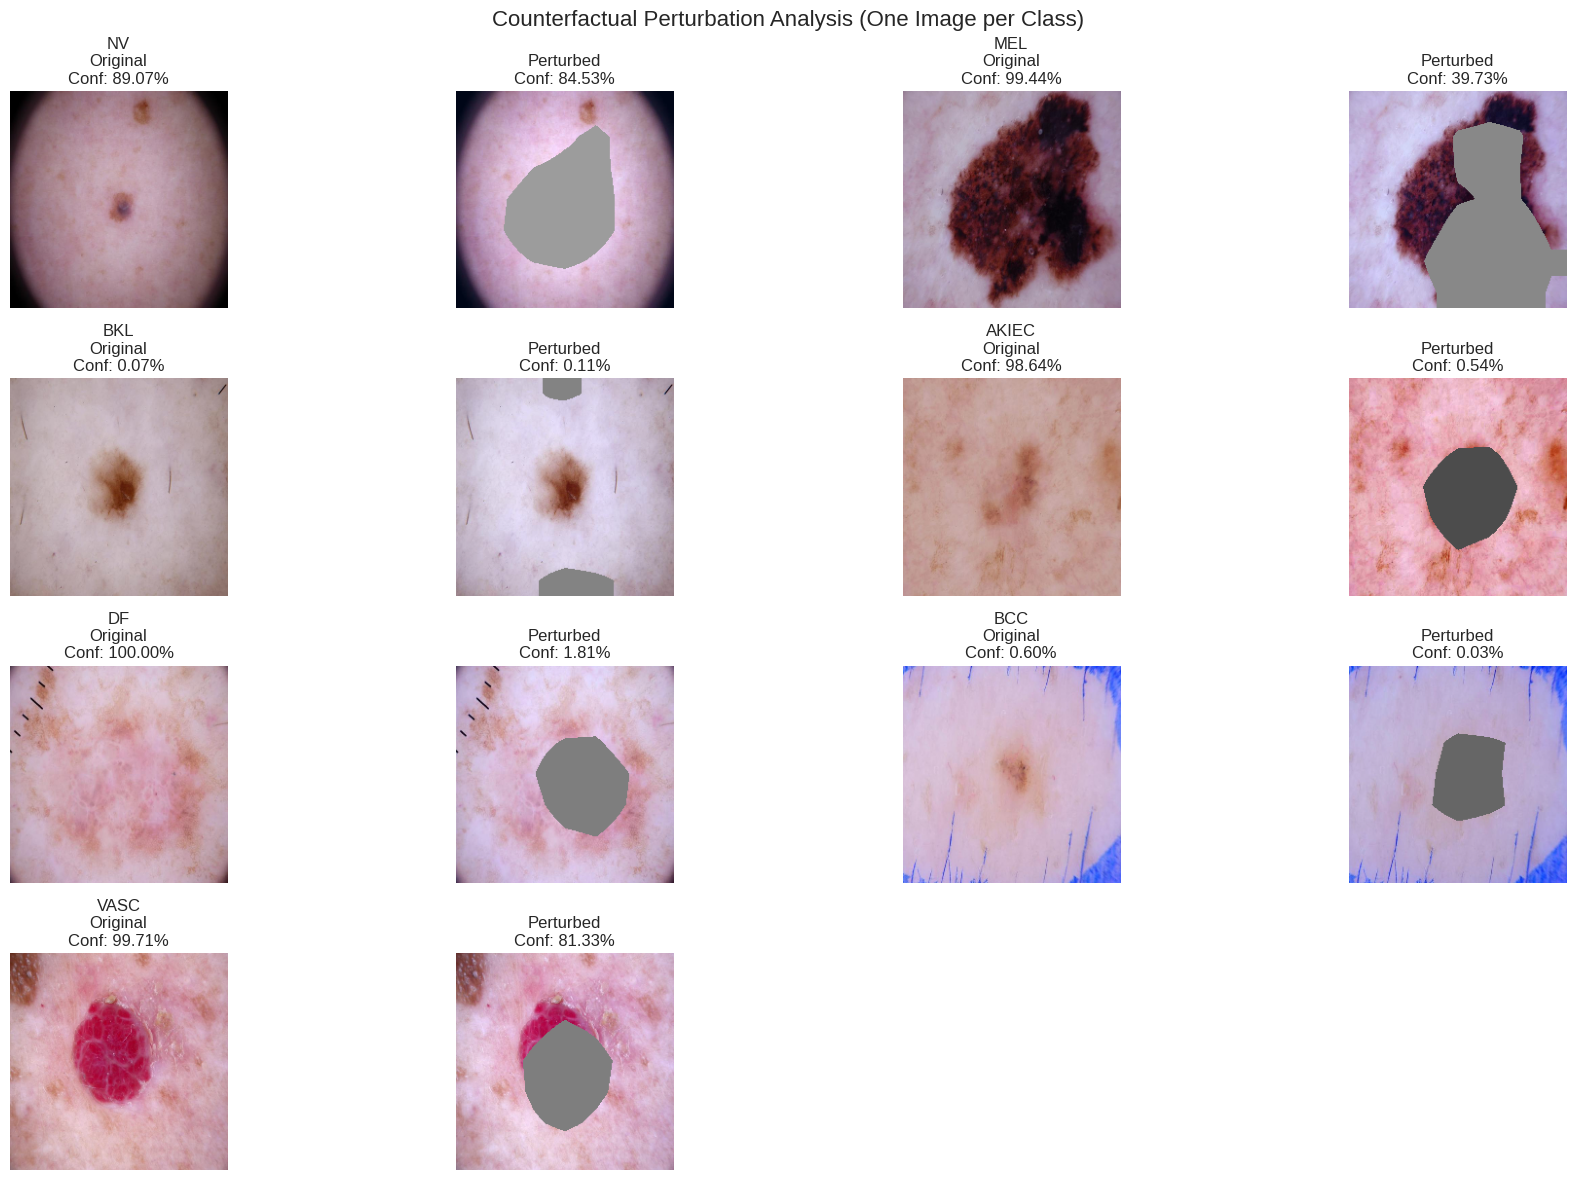

In [ ]:
import cv2
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.nn.functional as F

# ===== CONFIG =====
class_names = ["AKIEC", "BCC", "BKL", "DF", "MEL", "NV", "VASC"]

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

model.eval()
target_layer = model.layer4[-1]
gradcam = GradCAM(model, target_layer)

# ===== GET ONE IMAGE PER CLASS =====
def get_one_image_per_class(images_dir, labels_dir):
    paths = {}
    for img in os.listdir(images_dir):
        if not img.lower().endswith(".jpg"):
            continue

        label_path = os.path.join(labels_dir, img.replace(".jpg", ".txt"))
        if not os.path.exists(label_path):
            continue

        with open(label_path) as f:
            cls = int(f.readline().split()[0])

        if cls not in paths:
            paths[cls] = os.path.join(images_dir, img)

        if len(paths) == 7:
            break
    return paths

class_image_paths = get_one_image_per_class(VAL_IMAGES, VAL_LABELS)

# ===== PERTURBATION FUNCTION =====
def perturb_using_cam(img_tensor, cam, threshold=0.6):
    cam = cam / (cam.max() + 1e-8)
    mask = cam > threshold

    perturbed = img_tensor.clone()
    for c in range(3):
        perturbed[0, c][mask] = 0.0
    return perturbed

# ===== PLOT =====
plt.figure(figsize=(18, 12))
plot_idx = 1

for class_id, img_path in class_image_paths.items():
    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_np = img.astype(np.float32) / 255.0

    img_tensor = val_transform(img).unsqueeze(0).to(device)

    # Confidence BEFORE perturbation
    with torch.no_grad():
        probs_before = F.softmax(model(img_tensor), dim=1)
        conf_before = probs_before[0, class_id].item() * 100

    # Grad-CAM
    cam = gradcam.generate(img_tensor, class_id)
    cam = cv2.resize(cam, (224, 224))

    # Apply perturbation
    perturbed_tensor = perturb_using_cam(img_tensor, cam, threshold=0.6)

    # Confidence AFTER perturbation
    with torch.no_grad():
        probs_after = F.softmax(model(perturbed_tensor), dim=1)
        conf_after = probs_after[0, class_id].item() * 100

    # Convert perturbed image to numpy
    pert_np = perturbed_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    pert_np = (pert_np - pert_np.min()) / (pert_np.max() - pert_np.min() + 1e-8)

    # Plot Original
    plt.subplot(4, 4, plot_idx)
    plt.imshow(img_np)
    plt.title(f"{class_names[class_id]}\nOriginal\nConf: {conf_before:.2f}%")
    plt.axis("off")
    plot_idx += 1

    # Plot Perturbed
    plt.subplot(4, 4, plot_idx)
    plt.imshow(pert_np)
    plt.title(f"Perturbed\nConf: {conf_after:.2f}%")
    plt.axis("off")
    plot_idx += 1

plt.suptitle(
    "Counterfactual Perturbation Analysis (One Image per Class)",
    fontsize=16
)
plt.tight_layout()
plt.show()
